In [1]:
# import matplotlib.pyplot as plt
from sklearn import pipeline
from rdkit import Chem
import pandas as pd
import numpy as np
import sklearn
import scipy

In [2]:
rng = np.random.default_rng(seed=58)

In [3]:
df = pd.read_csv("data/processed_dataset_wo_metals.csv")

In [5]:
y = df["solubility"]
X = df.drop(["solubility", "smiles", "canon_smiles"], axis=1)

In [6]:
X.columns

Index(['energy', 'atomization_energy', 'homo_lumo_gap', 'ionization_energy',
       'electron_affinity', 'chemical_potential', 'molecular_dipole_norm',
       'molecular_quadrupole_principal_invariant_2',
       'molecular_quadrupole_principal_invariant_3',
       'molecular_polarizability_mean',
       ...
       'fr_sulfide', 'fr_sulfonamd', 'fr_sulfone', 'fr_term_acetylene',
       'fr_tetrazole', 'fr_thiazole', 'fr_thiocyan', 'fr_thiophene',
       'fr_unbrch_alkane', 'fr_urea'],
      dtype='str', length=276)

<Axes: >

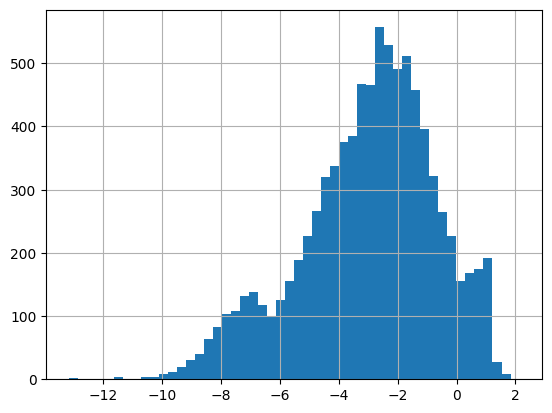

In [7]:
y.hist(bins=50)

In [41]:
X["molecular_quadrupole_principal_invariant_2"].max()

np.float64(-7.285537982560807e-09)

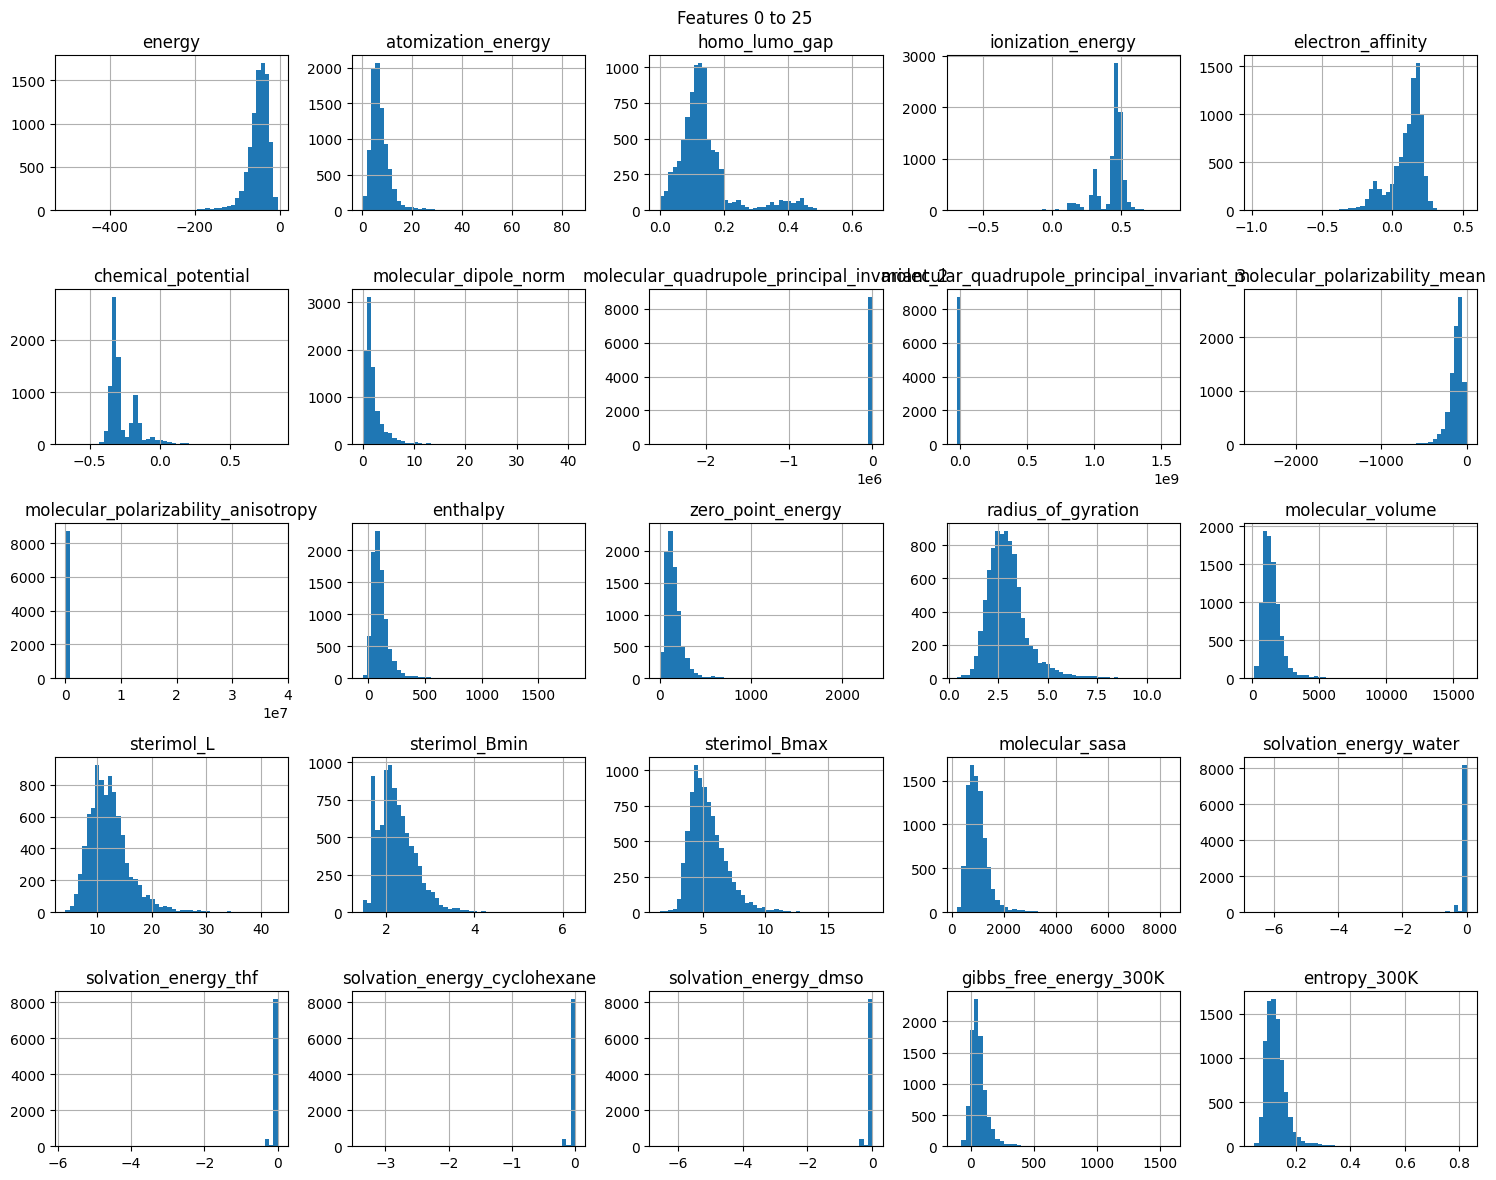

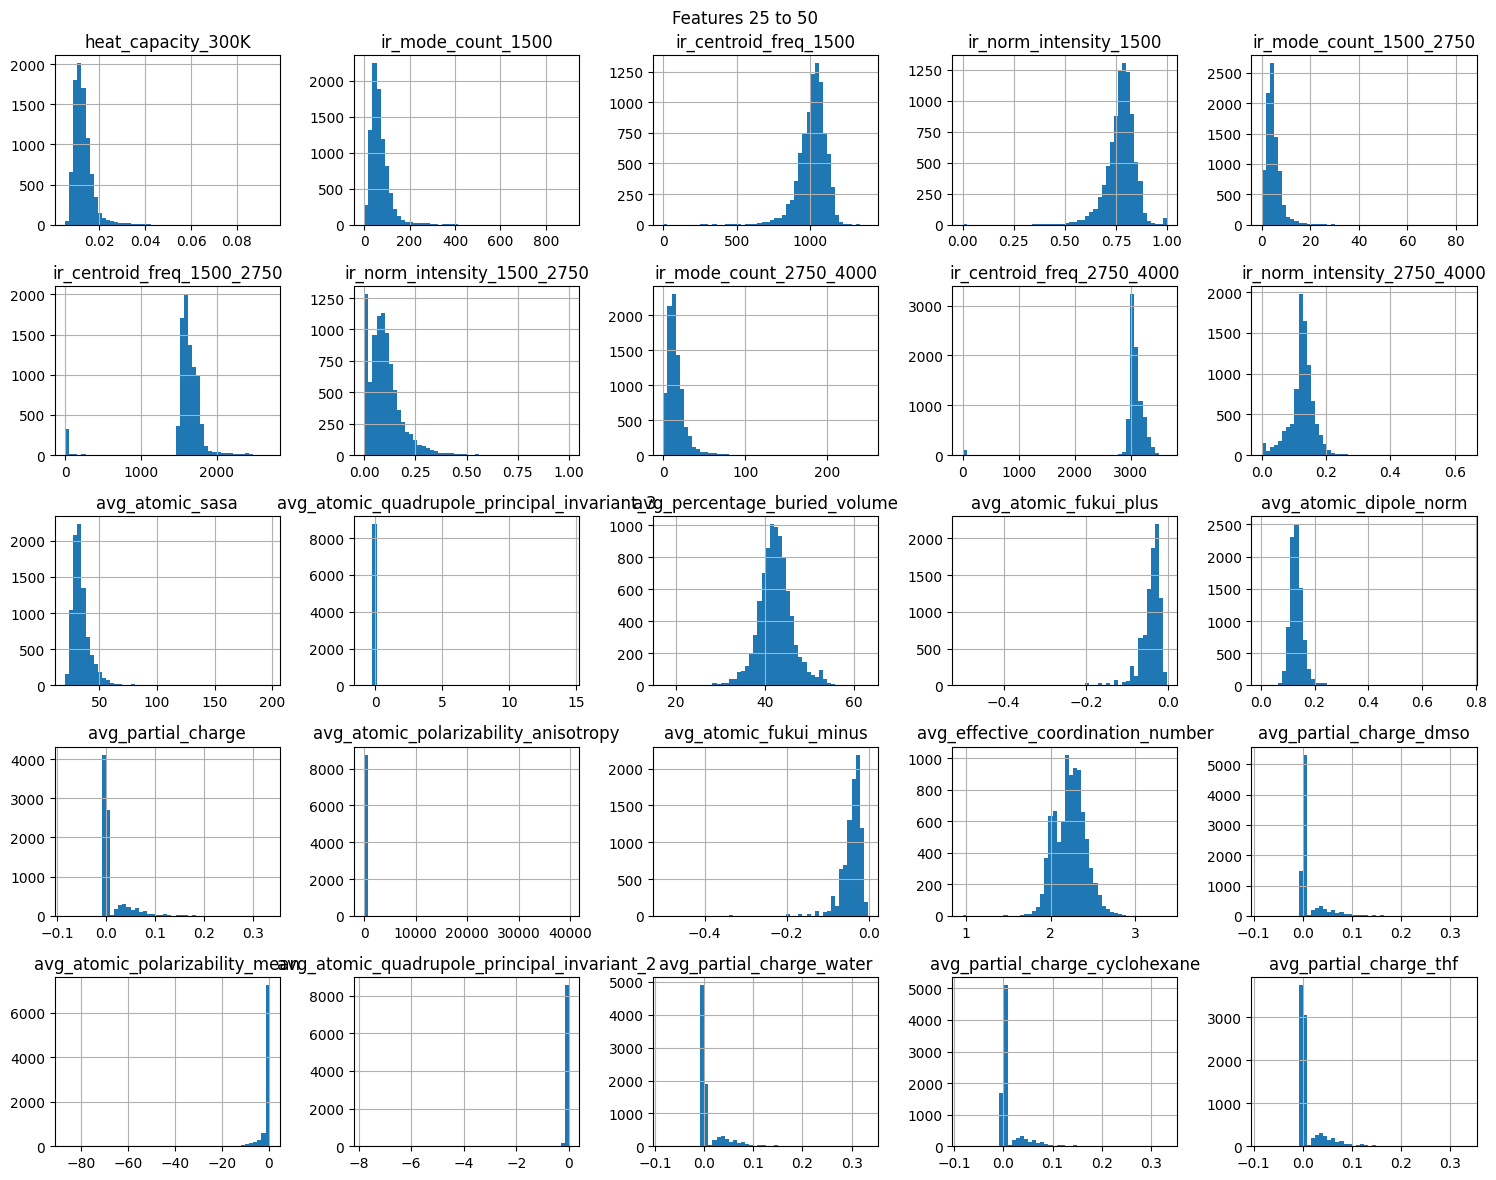

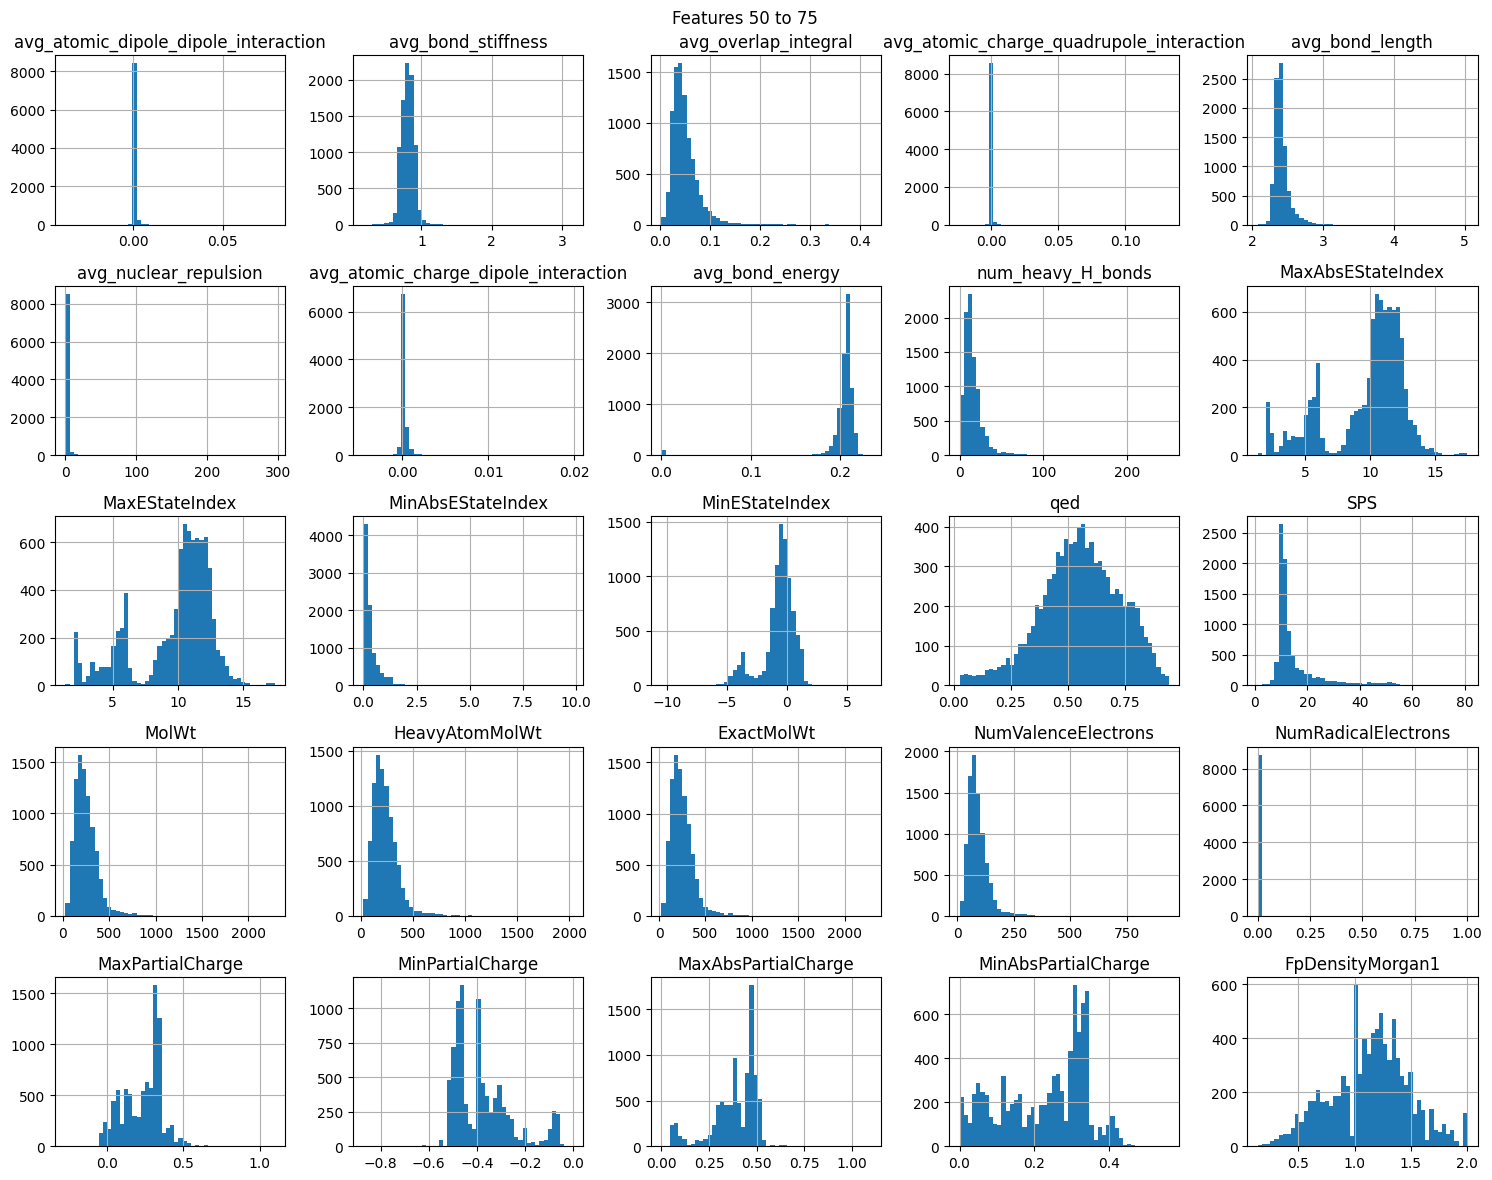

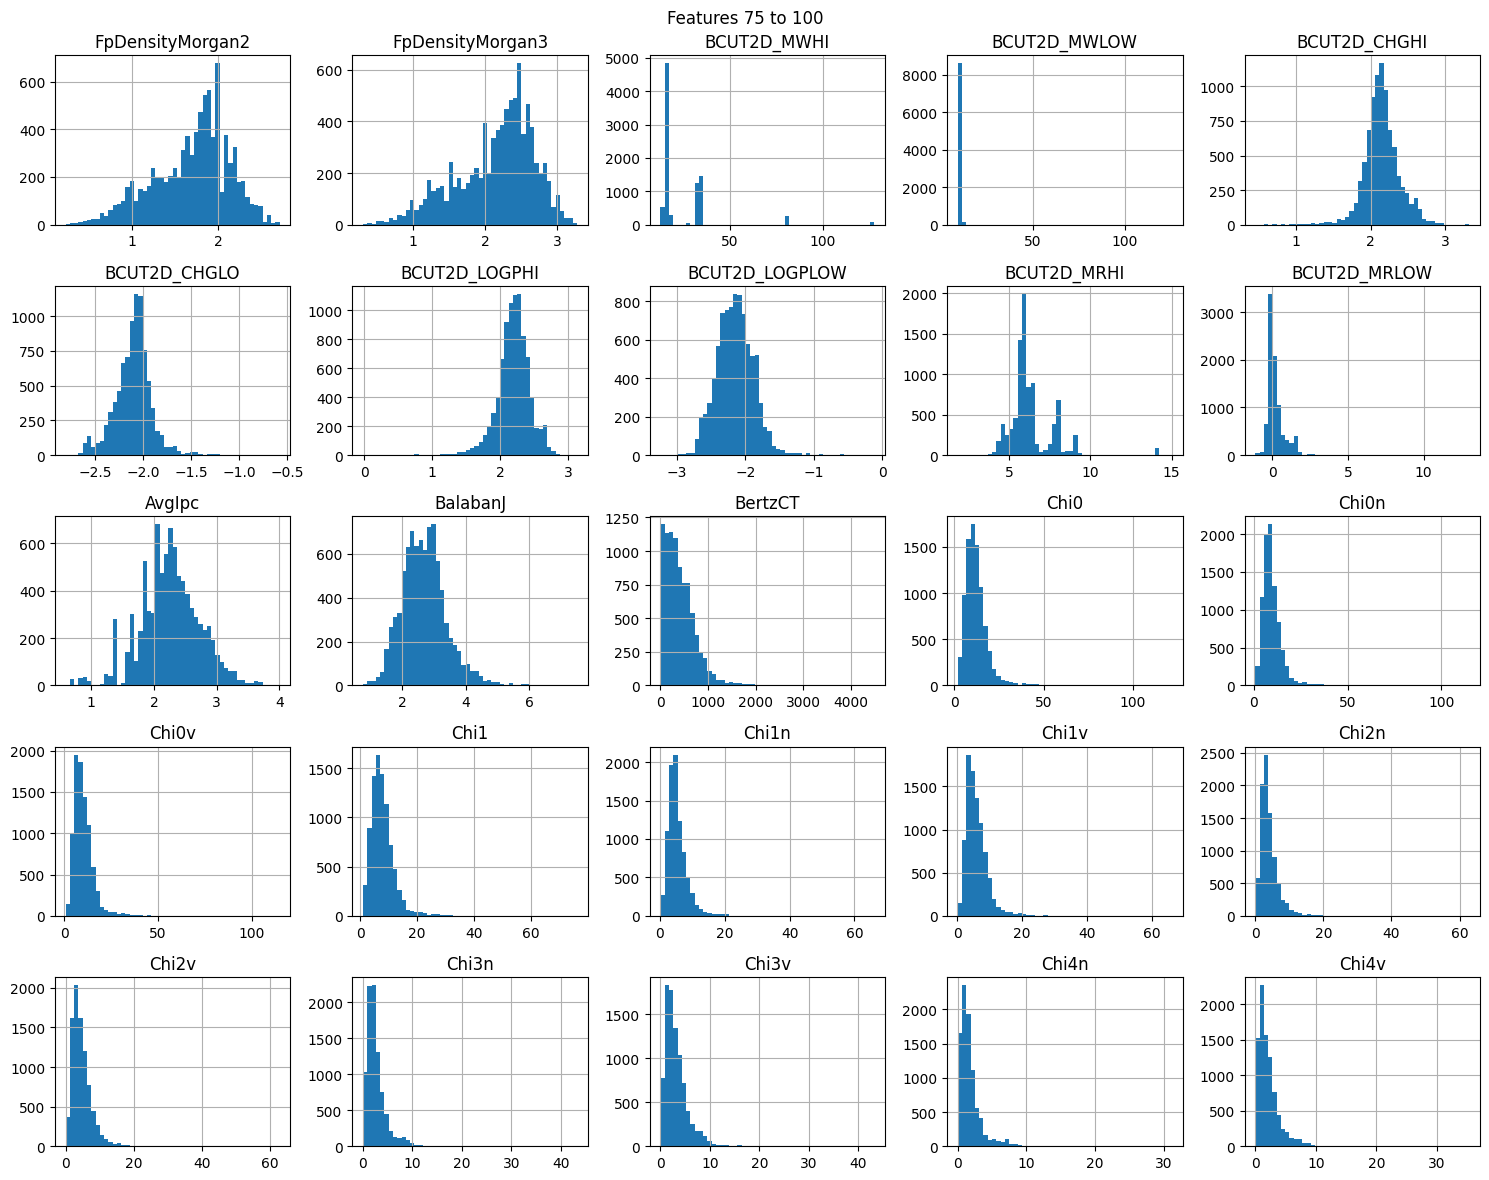

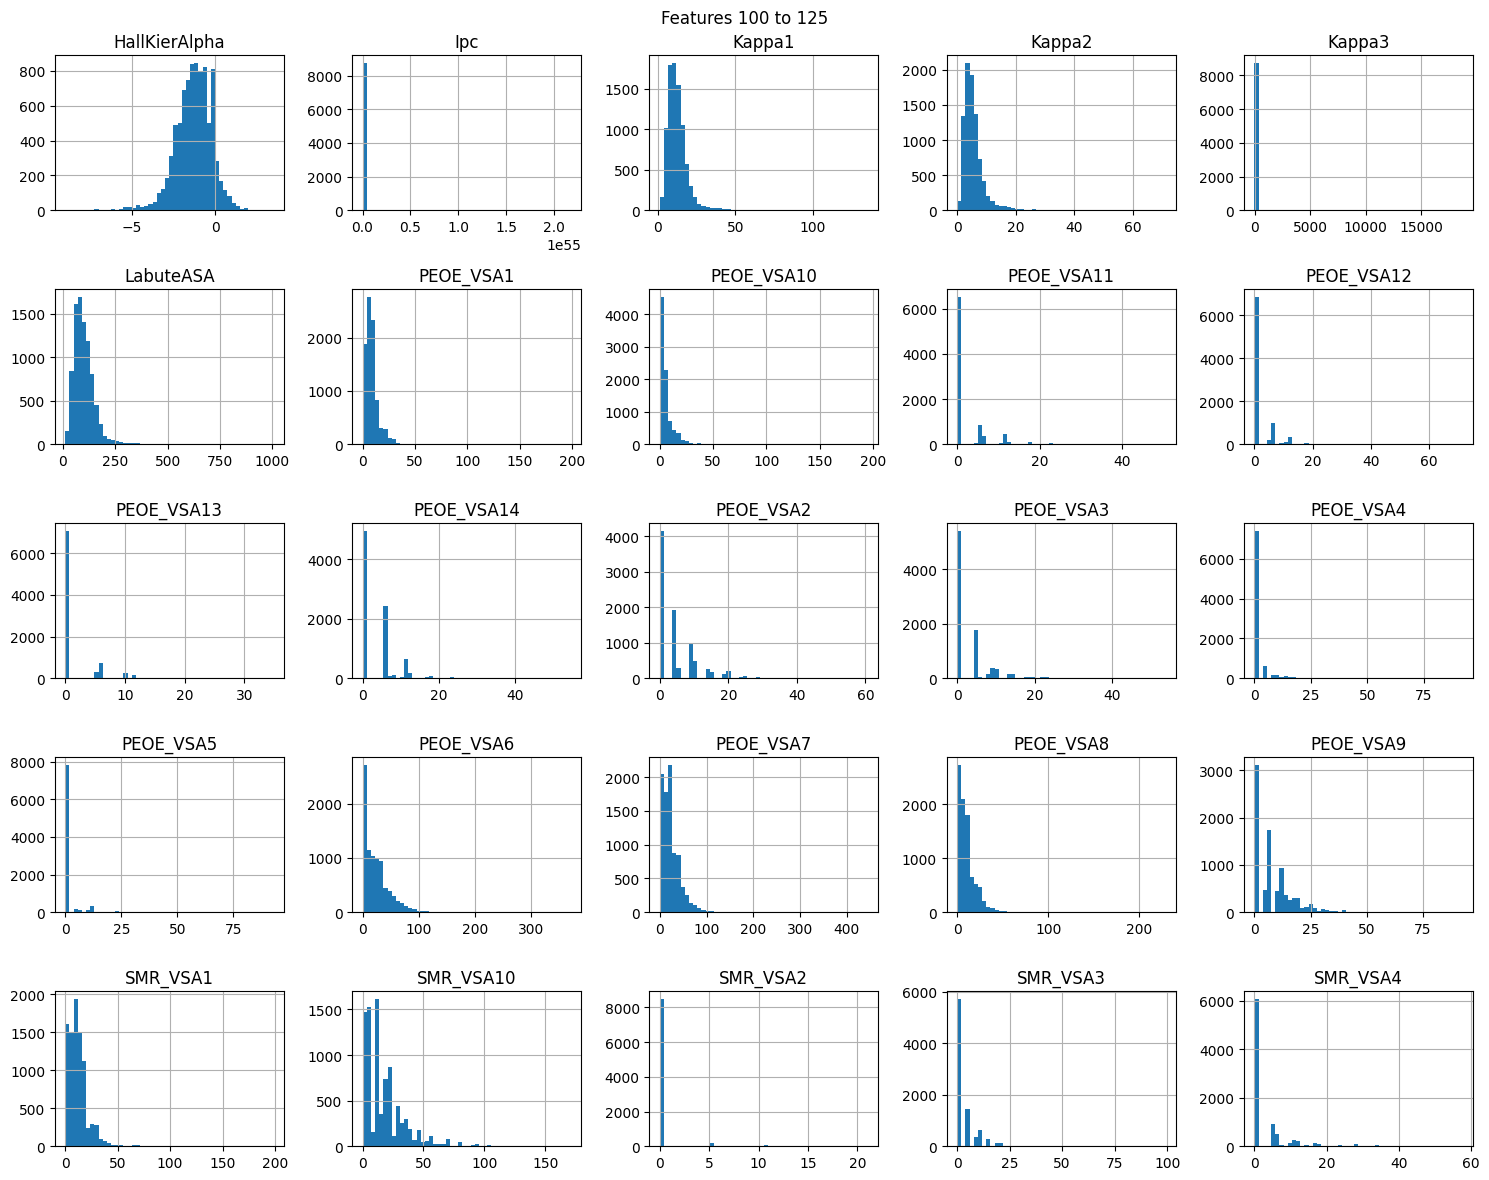

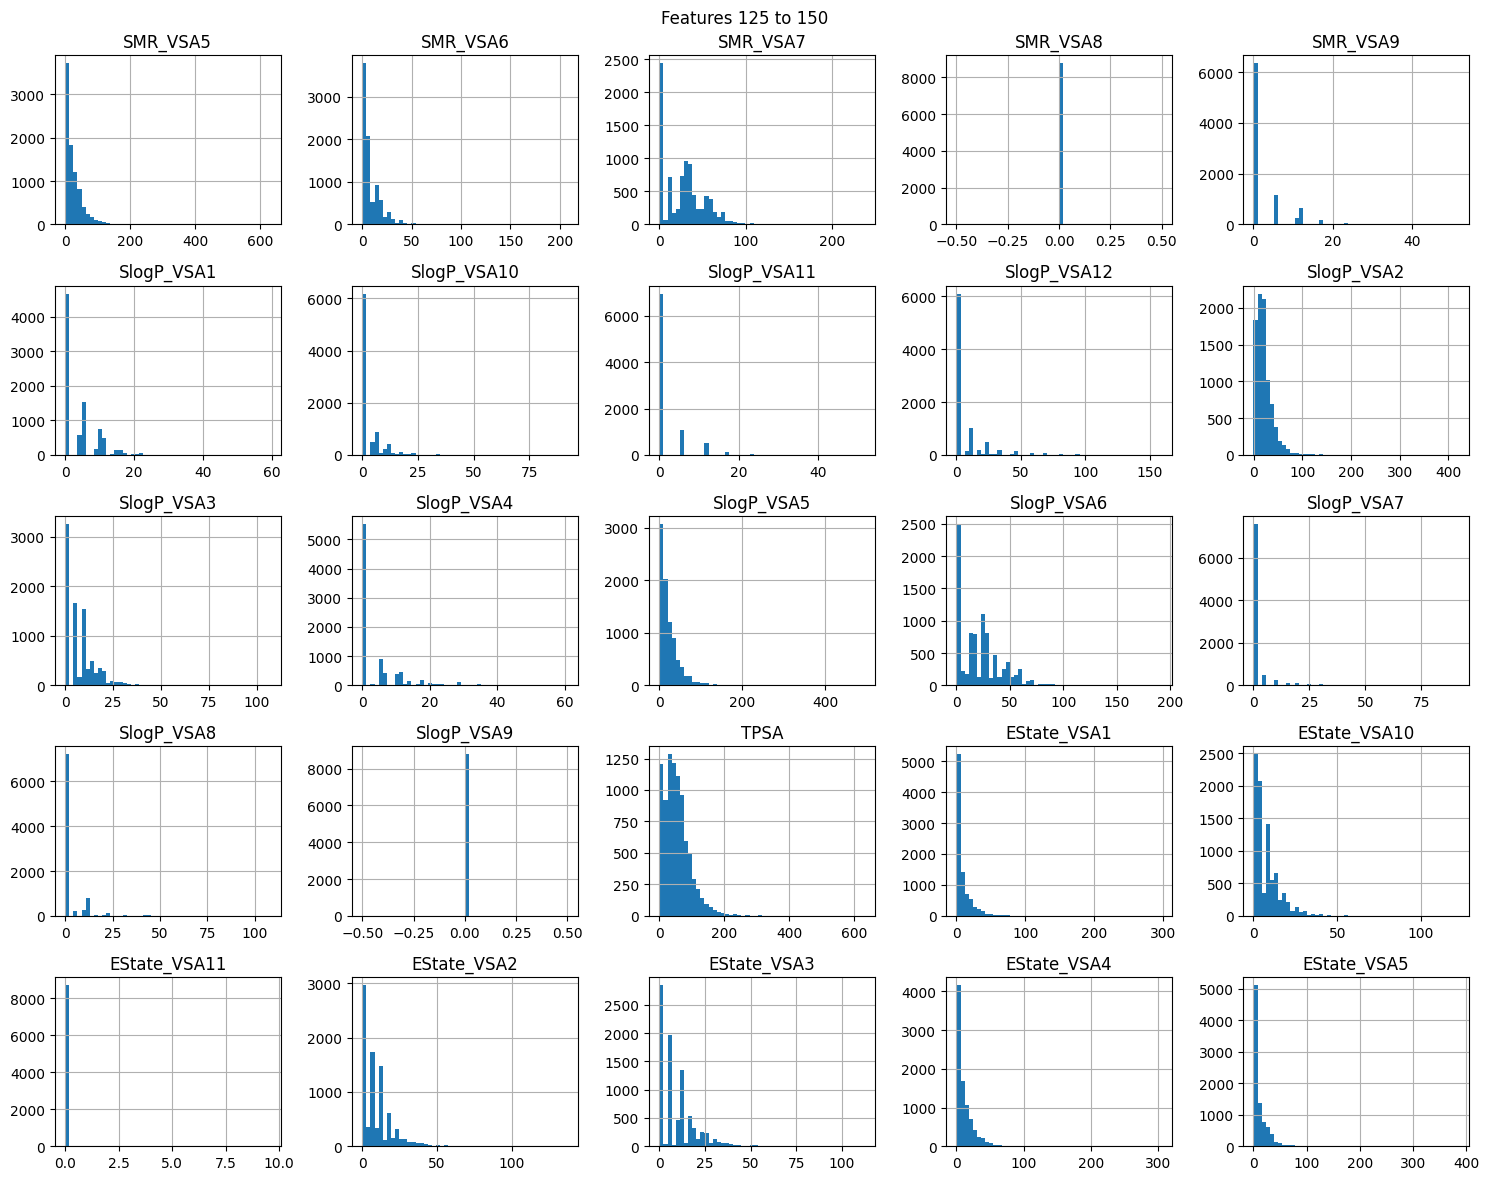

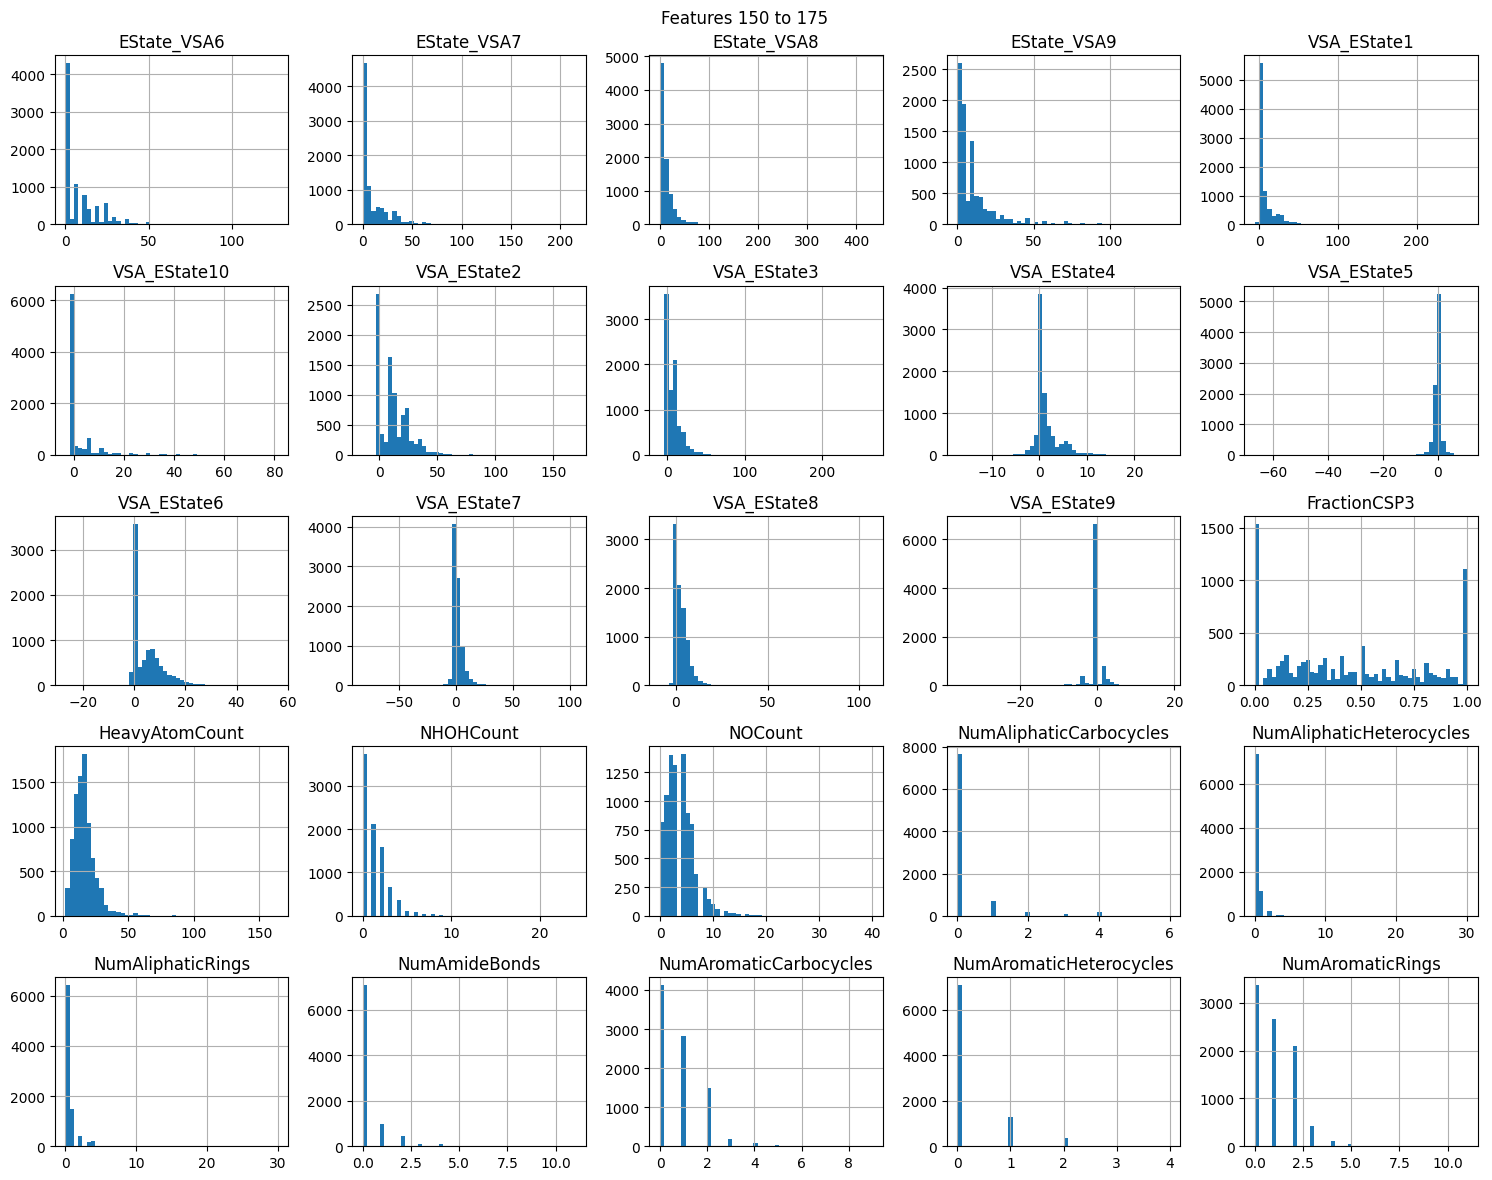

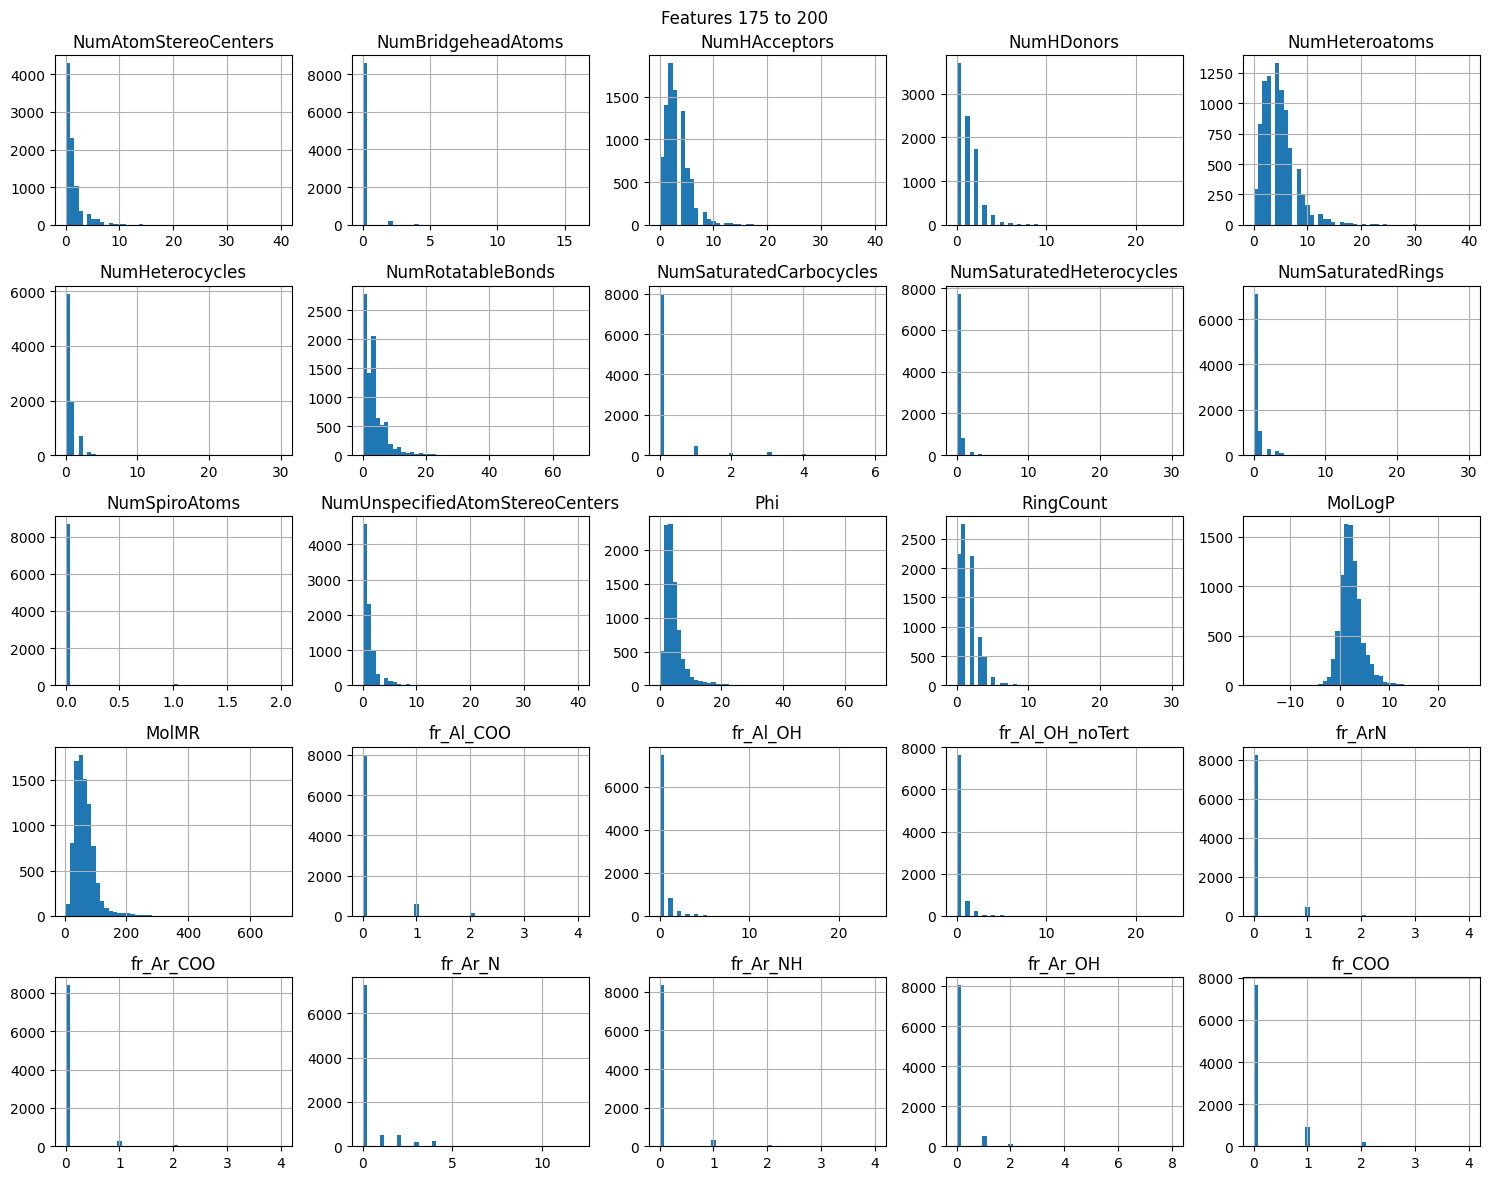

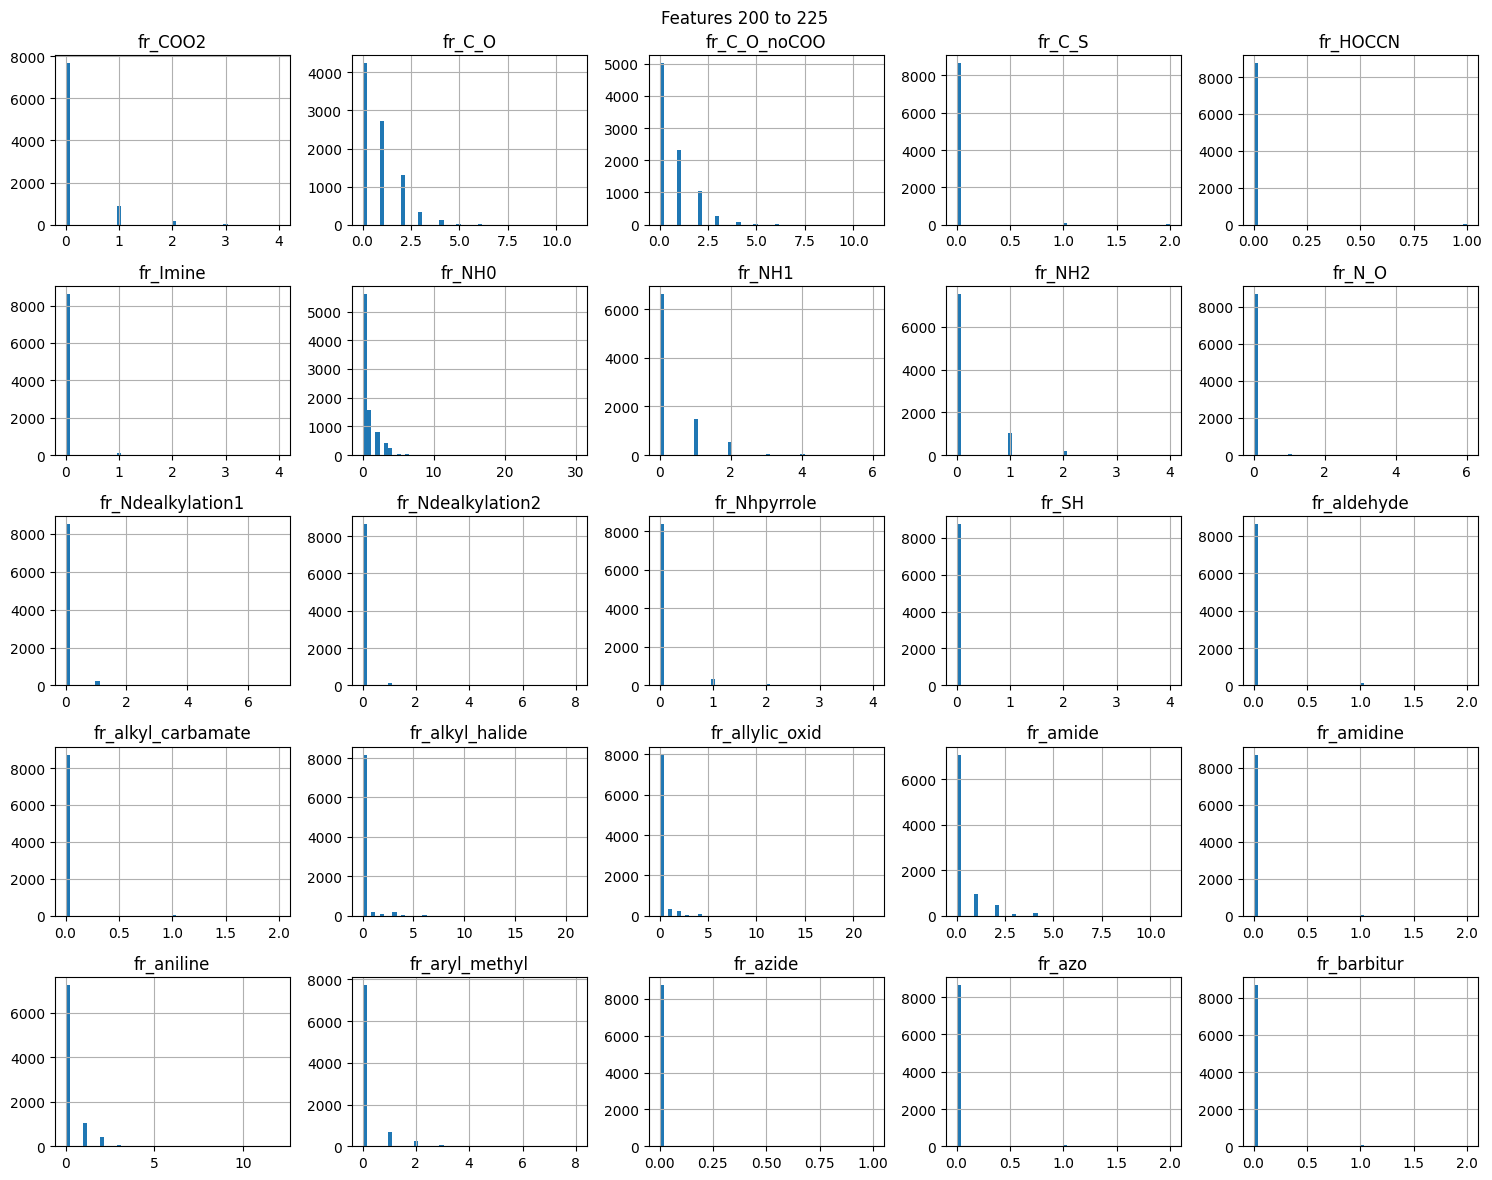

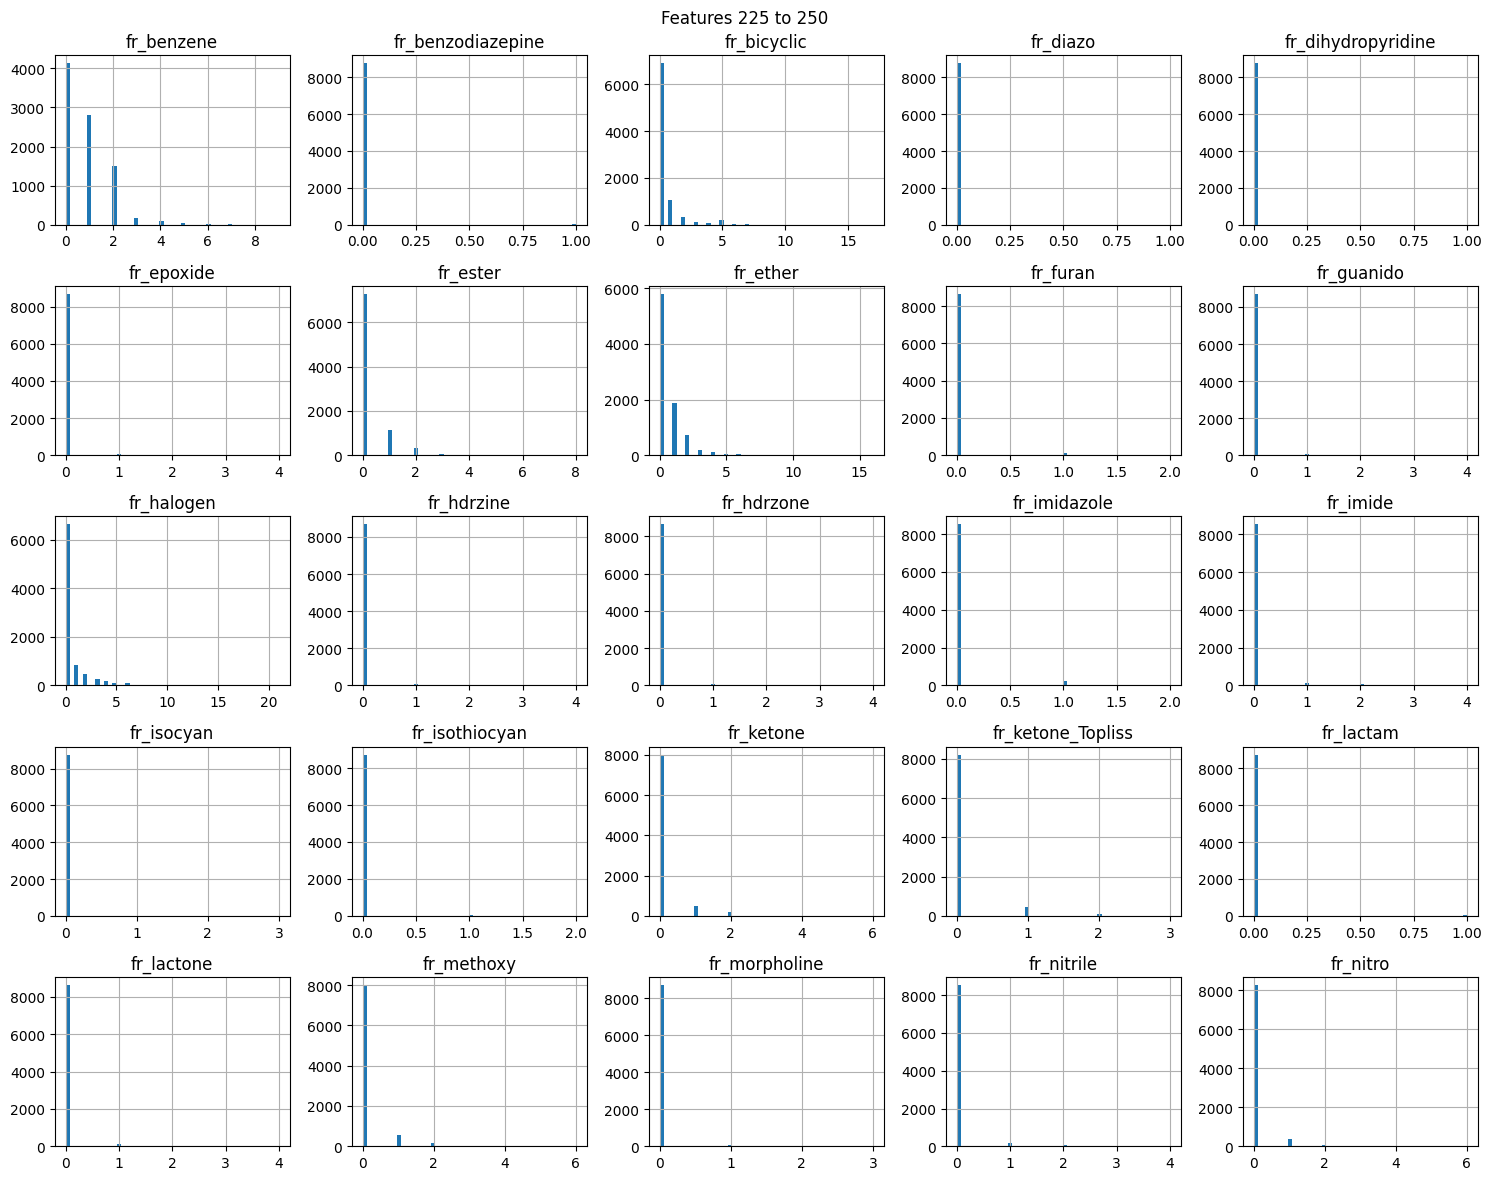

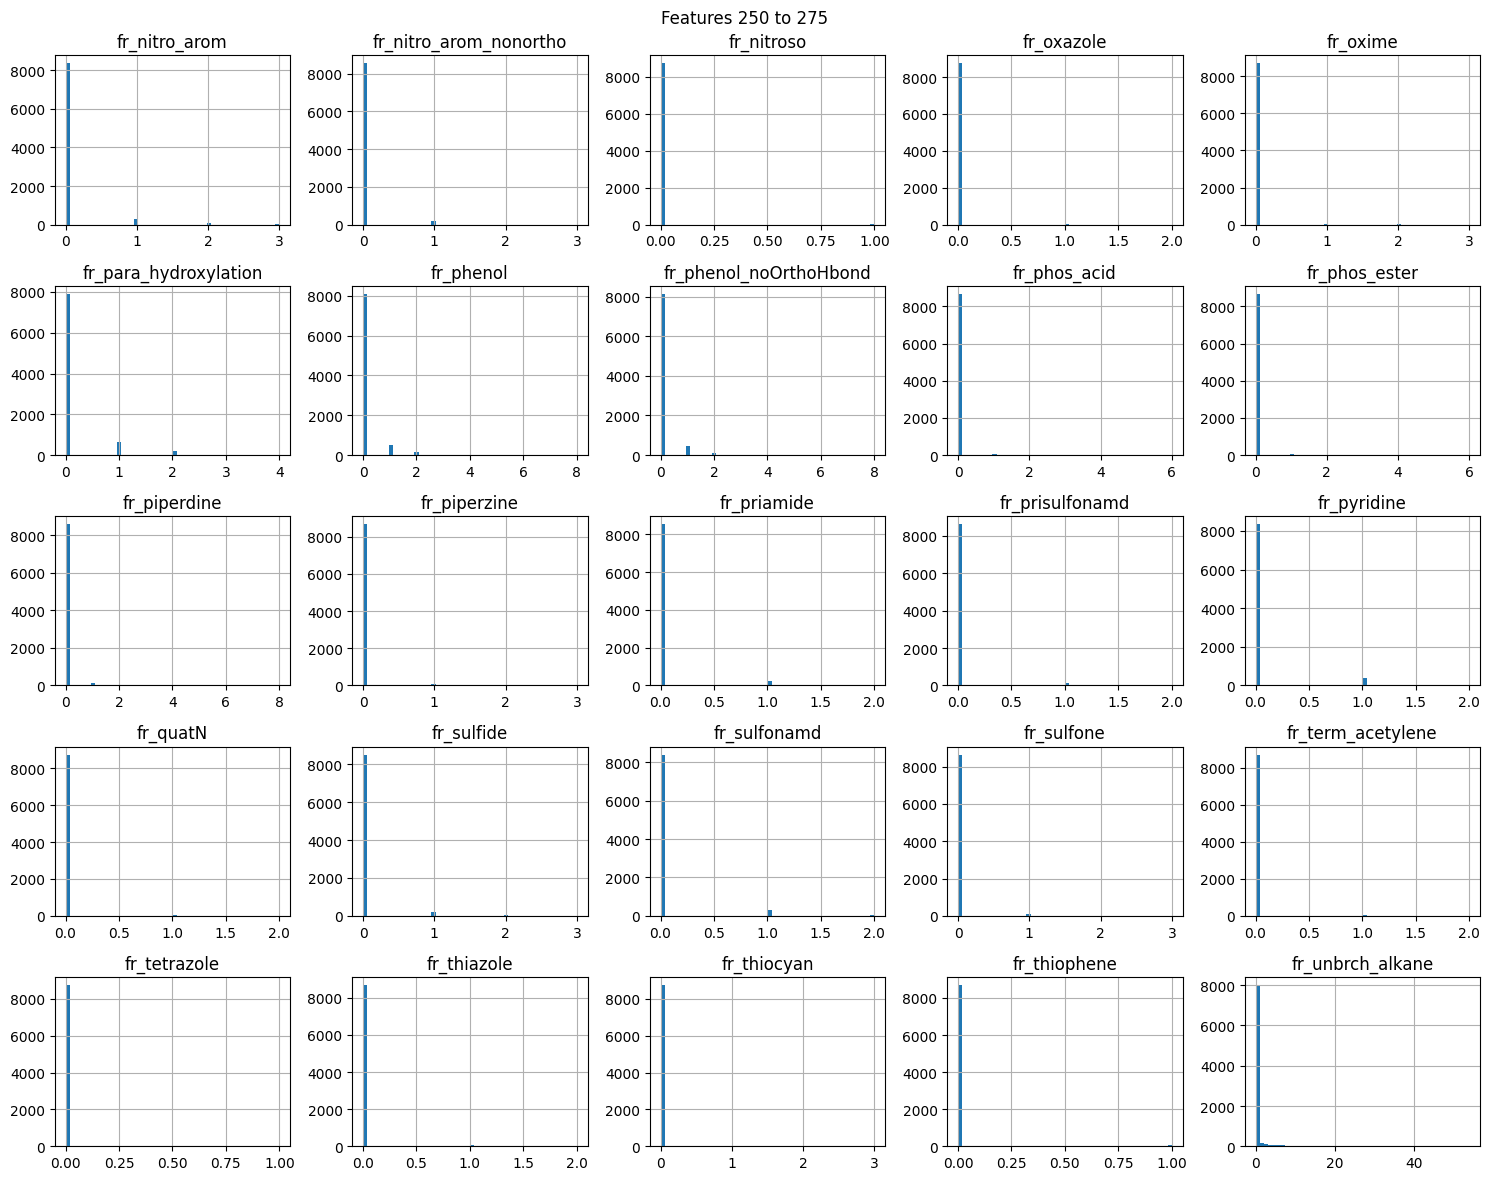

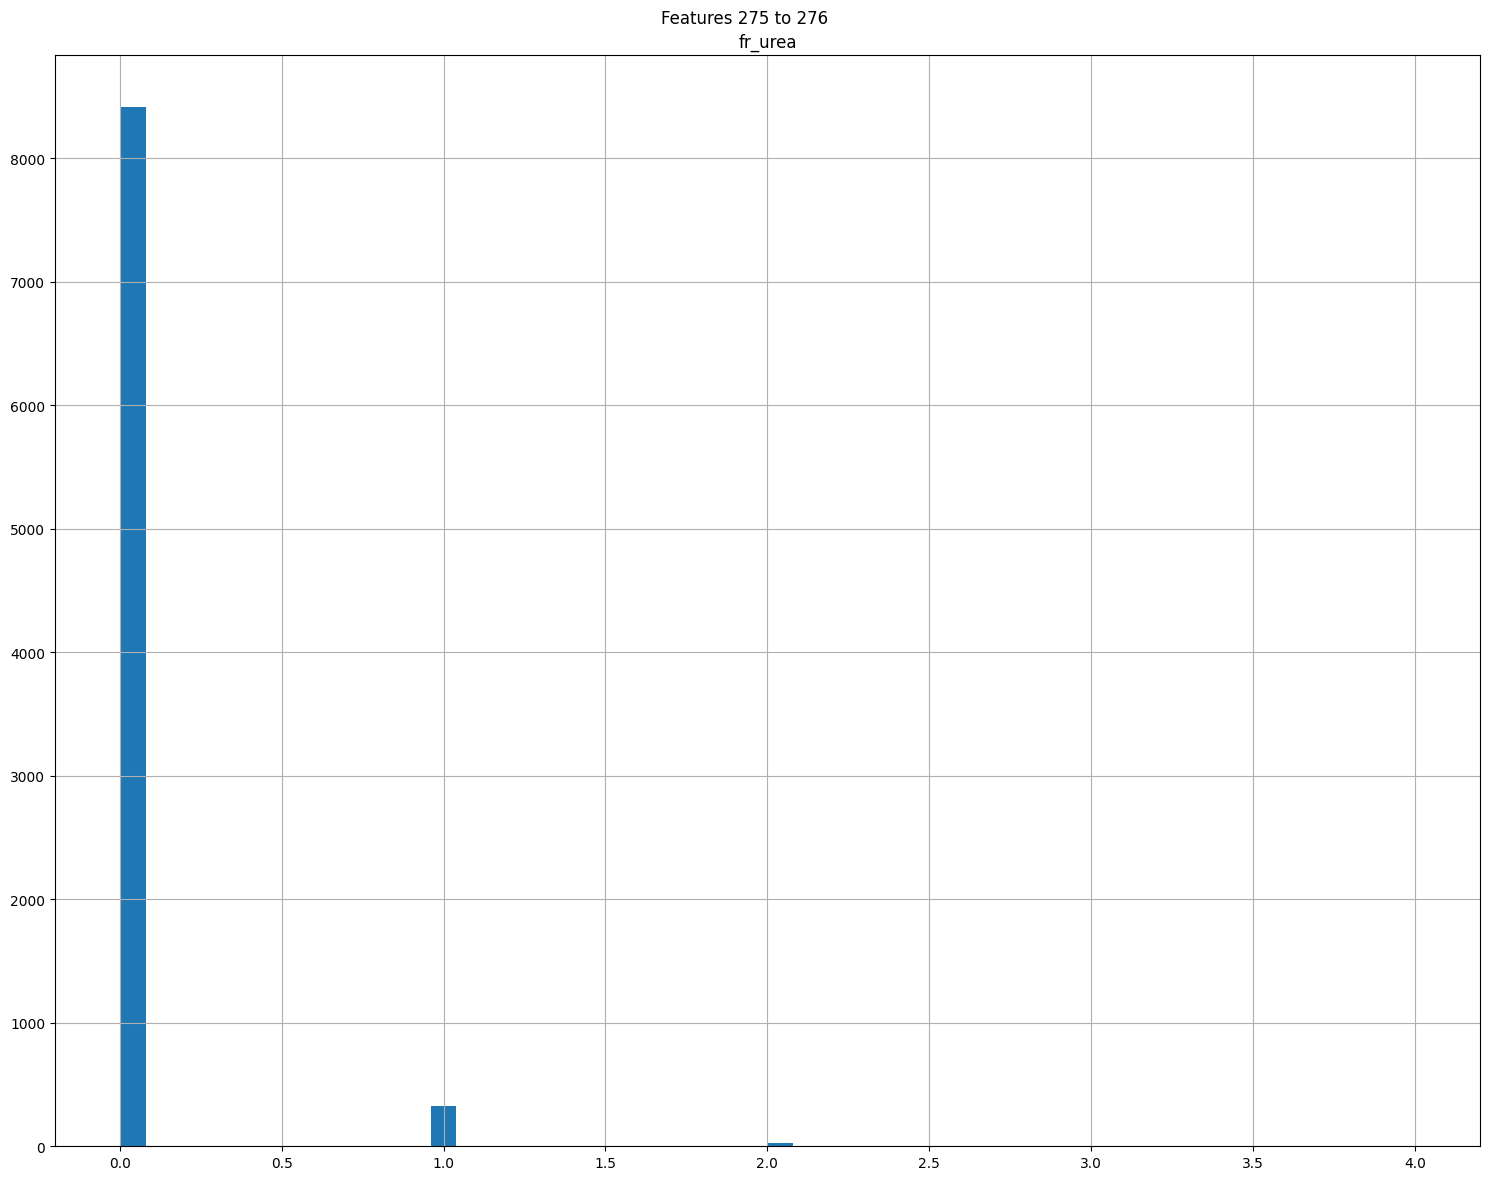

In [42]:
cols = X.columns
batch_size = 25

for i in range(0, len(cols), batch_size):
    try:
        batch = cols[i:i+batch_size]
        X[batch].hist(bins=50, figsize=(15, 12))
        plt.suptitle(f"Features {i} to {i+len(batch)}")
        plt.tight_layout()
        plt.show()
    except:
        print(batch)

1561343174.1536963
-22651023.575952195


<Axes: >

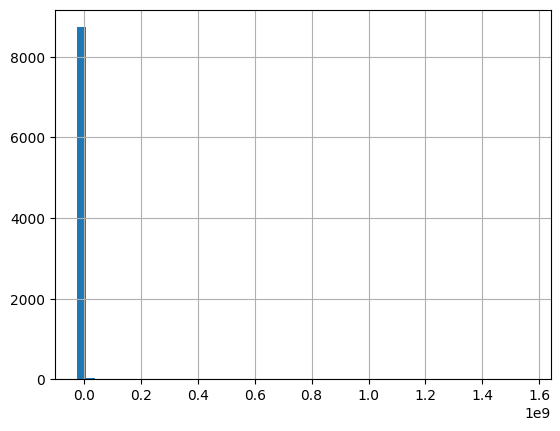

In [52]:
print(df["molecular_quadrupole_principal_invariant_3"].max())
print(df["molecular_quadrupole_principal_invariant_3"].min())
df["molecular_quadrupole_principal_invariant_3"].hist(bins=50)

In [8]:
def make_pipeline():
    return pipeline.Pipeline([
        ("scale", sklearn.preprocessing.RobustScaler()),
        ("predict", sklearn.linear_model.LinearRegression())
    ])



In [16]:
strange_one = df[df["molecular_quadrupole_principal_invariant_3"]==df["molecular_quadrupole_principal_invariant_3"].max()]

In [17]:
strange_one["canon_smiles"]

587    O=P(O)(O)CN(CCCCCCN(CP(=O)(O)O)CP(=O)(O)O)CCCC...
Name: canon_smiles, dtype: str

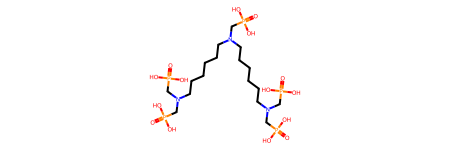

In [9]:
Chem.MolFromSmiles('O=P(O)(O)CN(CCCCCCN(CP(=O)(O)O)CP(=O)(O)O)CCCCCCN(CP(=O)(O)O)CP(=O)(O)O')

In [10]:
strange_one = df[df["molecular_quadrupole_principal_invariant_2"]==df["molecular_quadrupole_principal_invariant_2"].max()]

In [11]:
strange_one["canon_smiles"].to_numpy()

array(['FS(F)(F)(F)(F)F'], dtype=object)

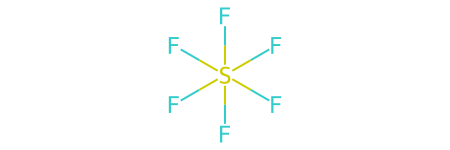

In [12]:
Chem.MolFromSmiles('FS(F)(F)(F)(F)F')

In [13]:
strange_one = df[df["molecular_polarizability_anisotropy"]==df["molecular_polarizability_anisotropy"].max()]

In [14]:
strange_one["canon_smiles"].to_numpy()

array(['CCCCCCCC/C=C/CCCCCCCCO[P+](=O)OCCCCCCCC/C=C/CCCCCCCC'],
      dtype=object)

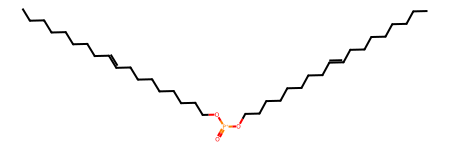

In [15]:
Chem.MolFromSmiles('CCCCCCCC/C=C/CCCCCCCCO[P+](=O)OCCCCCCCC/C=C/CCCCCCCC')